Drift Distance Prediction using Neural Network: Pixel Only
==========================================================

- v0.1.1
- Train a neural network; using minimal input variables and the default parameters, i.e. hidden_layer_sizes = (100, 50)
- Difference from v0.1:
    - Use the GAMPixPy simulation with 3 pre-samples before the trigger time
    - GAMPixPy trigger algorithms ask the triggered tick has the true signal greater than 3&times;50e<sup>-</sup>

- NOT using the tile readout for the comparison.
    - This is to justify that we still need the tile readout to get a good result.

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

import matplotlib.pyplot as plt
import matplotlib.colors as colors

In [2]:
infile = '/Users/yuntse/data/lartpc_rd/gampix/nn/radiologicals/gampixpy_fullgeoanatruth-vd-reduced_g4_00_2Mhz_segmentlabel_lowtrig_5mmpitch_good_r3sd_presample_pixel.csv'

In [3]:
df = pd.read_csv(infile, header = 0)
df

,tile_id,event id,start t,tile x,tile y,charge,fit_amp,fit_mu,fit_sigma,fit_rmse,...,ratio,ratio_3sd,ratio_fit,ratio_fit_3sd,E,z_avg,drift_avg,dQdn,ratio_3sd_pixel,dQdn_pixel
0,0,0,5806.4365,-1065.0,-575.0,965.778880,173.146760,1.800038,0.939798,50.072464,...,0.817486,0.159968,1.081924,0.000000,0.103476,-308.29733,633.297360,482.889440,0.195682,394.755428
1,2,0,-3550.5635,-1055.0,-575.0,234.433332,43.891174,0.731231,1.514144,58.922040,...,2.075628,0.952930,0.983764,0.000000,0.034409,323.14770,1.852295,234.433332,0.459104,486.596345
2,3,0,-3111.0635,-1055.0,-575.0,1132.180275,1049.915800,1.932631,0.268530,58.317420,...,1.473346,1.007987,1.021464,0.822217,0.109424,306.18195,18.818054,566.090137,0.684148,834.046382
3,4,0,-3154.5635,-1055.0,-565.0,671.969728,673.100800,1.531063,0.240818,37.237630,...,1.655211,1.407073,1.114470,0.802374,0.086997,229.34247,95.657530,335.984864,0.850087,556.125693
4,6,0,3327.9365,-1055.0,-495.0,585.712231,358.198330,1.527334,0.361652,73.776800,...,1.586672,1.277588,0.995704,0.878903,0.067363,313.68454,11.315460,585.712231,0.805200,929.333077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
705207,888942,999,-3108.3162,-735.0,-485.0,1205.931701,767.312600,1.814874,0.362555,42.048855,...,1.457014,1.207953,1.072088,0.932395,0.112241,301.07280,23.927185,602.965850,0.829061,878.529394
705208,888943,999,-3057.3162,-735.0,-485.0,4061.857259,2146.497600,1.945175,0.366560,46.033340,...,1.034290,0.972351,1.018388,1.018214,0.243623,292.87340,32.126587,2030.928630,0.940115,2100.569498
705209,888944,999,2226.1838,-735.0,-365.0,1370.368824,532.412540,1.576690,0.344328,70.419945,...,0.629773,0.505224,0.824121,0.812401,0.086229,318.06238,6.937622,1370.368824,0.802231,863.021308
705210,888945,999,2381.1838,-735.0,-355.0,34824.065399,4619.398400,5.120800,1.504715,91.878580,...,0.990922,0.849475,1.002991,0.857276,1.790287,-314.51718,639.517200,2487.433243,0.857257,2464.853243


## Training

In [4]:
feature_cols = ['charge_sum', 'charge_3sd_sum', 'ratio_3sd_pixel', 'fit_sigma_mean', 'dQdn_pixel'] 
target_col = 'drift_avg'

In [5]:
X = df[feature_cols]
y = df[target_col]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
model = MLPRegressor(
    hidden_layer_sizes = (100, 50),
    activation = "relu",
    solver = "adam",
    learning_rate_init = 0.001,
    max_iter = 1000,
    random_state = 42,
    verbose = True
)
model.fit(X_train_scaled, y_train)

Iteration 1, loss = 8479.85201726
Iteration 2, loss = 4578.18998971
Iteration 3, loss = 4434.65031215
Iteration 4, loss = 4340.35990812
Iteration 5, loss = 4276.46039777
Iteration 6, loss = 4230.10624253
Iteration 7, loss = 4194.69811914
Iteration 8, loss = 4169.76232384
Iteration 9, loss = 4149.96723483
Iteration 10, loss = 4134.04896048
Iteration 11, loss = 4121.42575604
Iteration 12, loss = 4114.33857816
Iteration 13, loss = 4106.42797572
Iteration 14, loss = 4099.28014701
Iteration 15, loss = 4094.16537977
Iteration 16, loss = 4089.18110836
Iteration 17, loss = 4085.81914333
Iteration 18, loss = 4080.55025535
Iteration 19, loss = 4079.08308416
Iteration 20, loss = 4076.23601615
Iteration 21, loss = 4073.25154937
Iteration 22, loss = 4069.83333318
Iteration 23, loss = 4067.08098446
Iteration 24, loss = 4065.08247629
Iteration 25, loss = 4062.61574399
Iteration 26, loss = 4061.62322238
Iteration 27, loss = 4060.52893553
Iteration 28, loss = 4057.59885364
Iteration 29, loss = 4056.592

MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42,
             verbose=True)

## Predicting

In [9]:
score = model.score(X_test_scaled, y_test)
print("Test R^2:", score)

Test R^2: 0.8052180804867701


In [10]:
preds = model.predict(X_test_scaled)

In [11]:
# Scale all feature rows using the scaler fit on training data
X_scaled = scaler.transform(df[feature_cols])

# Predict
df["pred_drift"] = model.predict(X_scaled)

In [12]:
# Save whether this row is used for training or testing
df["isTraining"] = True
df.loc[X_test.index, "isTraining"] = False

In [13]:
outfile = '/Users/yuntse/data/lartpc_rd/gampix/nn/radiologicals/gampixpy_fullgeoanatruth-vd-reduced_g4_00_2Mhz_segmentlabel_lowtrig_5mmpitch_good_r3sd_nn0.1.1_noTile.csv'

In [14]:
df.to_csv(outfile, index = False)

### Test sample

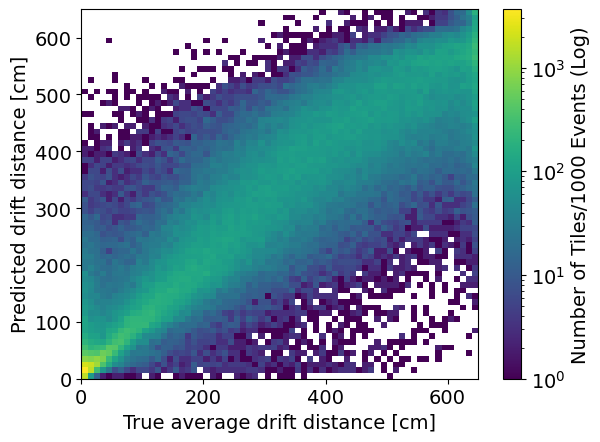

In [15]:
plt.rcParams.update({"font.size": 14})
fig, ax = plt.subplots()

h = ax.hist2d(y_test, preds, bins = (65, 65), range = [[0, 650], [0, 650]], cmap = 'viridis', norm = colors.LogNorm())

ax.set_xlabel('True average drift distance [cm]')
ax.set_ylabel('Predicted drift distance [cm]')
ax.set_xlim([0, 650])
ax.set_ylim([0, 650])

cbar = fig.colorbar(h[3])
# cbar.ax.tick_params( labelsize = fonts)     # ticks (numbers)
cbar.set_label("Number of Tiles/1000 Events (Log)") 

### Entire sample

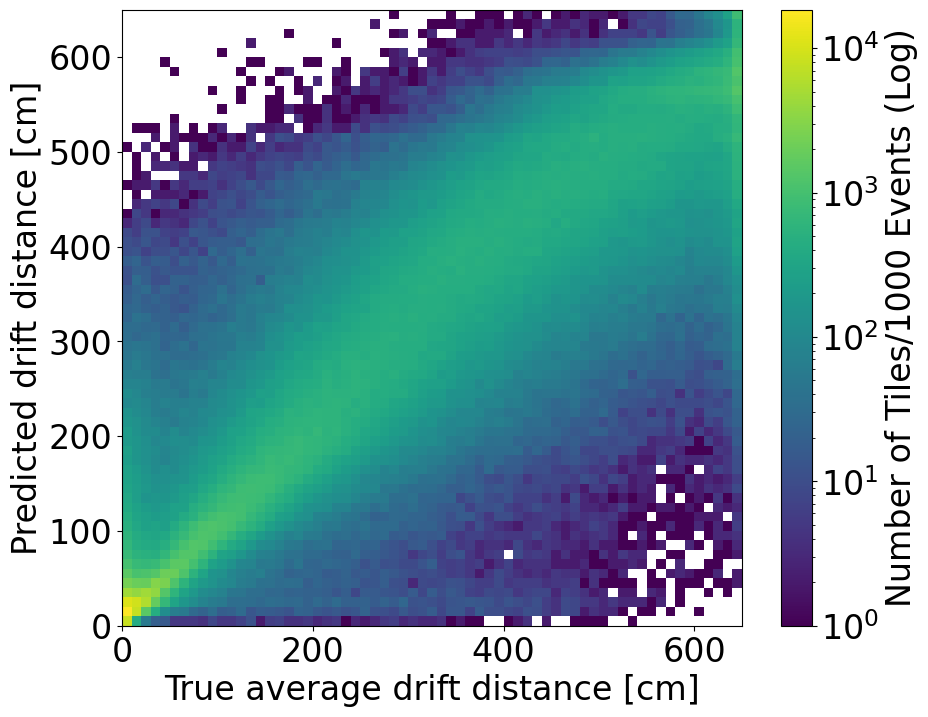

In [16]:
plt.rcParams.update({"font.size": 24,
                     "axes.labelsize": 24,
                     "xtick.labelsize": 24,
                     "ytick.labelsize": 24,})
fig, ax = plt.subplots(figsize = (10, 8))

h = ax.hist2d(df['drift_avg'], df['pred_drift'], bins = (65, 65), range = [[0, 650], [0, 650]], cmap = 'viridis', norm = colors.LogNorm())

ax.set_xlabel('True average drift distance [cm]')
ax.set_ylabel('Predicted drift distance [cm]')
ax.set_xlim([0, 650])
ax.set_ylim([0, 650])

cbar = fig.colorbar(h[3])
# cbar.ax.tick_params( labelsize = fonts)     # ticks (numbers)
cbar.set_label("Number of Tiles/1000 Events (Log)") 

In [17]:
len(preds)

141043

## Resolution

(-1.0, 1.0)

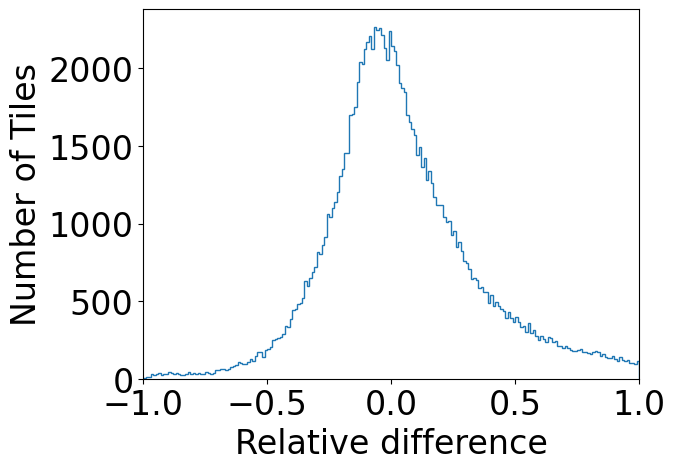

In [18]:
fig, ax = plt.subplots()
plt.rcParams.update({"font.size": 14})

ax.hist((preds - y_test)/y_test, bins = np.linspace(-1, 1, 201), histtype = 'step')

ax.set_xlabel('Relative difference')
ax.set_ylabel('Number of Tiles')
ax.set_xlim([-1, 1])

In [19]:
import seaborn as sns

In [20]:
df["drift_avg"].min(), df["drift_avg"].max()

(-0.039916992, 650.01514)

In [21]:
# example: df has columns 'drift_avg' and 'pred_drift'

# residual / difference
df["drift_diff"] = df["pred_drift"] - df["drift_avg"]

# make 25 cm bins for drift_avg
bin_width = 25
bins = np.arange(0, 675, bin_width)

df["drift_bin"] = pd.cut(df["drift_avg"], bins = bins, right = False)

In [22]:
df["drift_bin_label"] = df["drift_bin"].apply(lambda x: f"{int(x.left)}–{int(x.right)}")

Text(0, 0.5, 'Predicted - True drift distance [cm]')

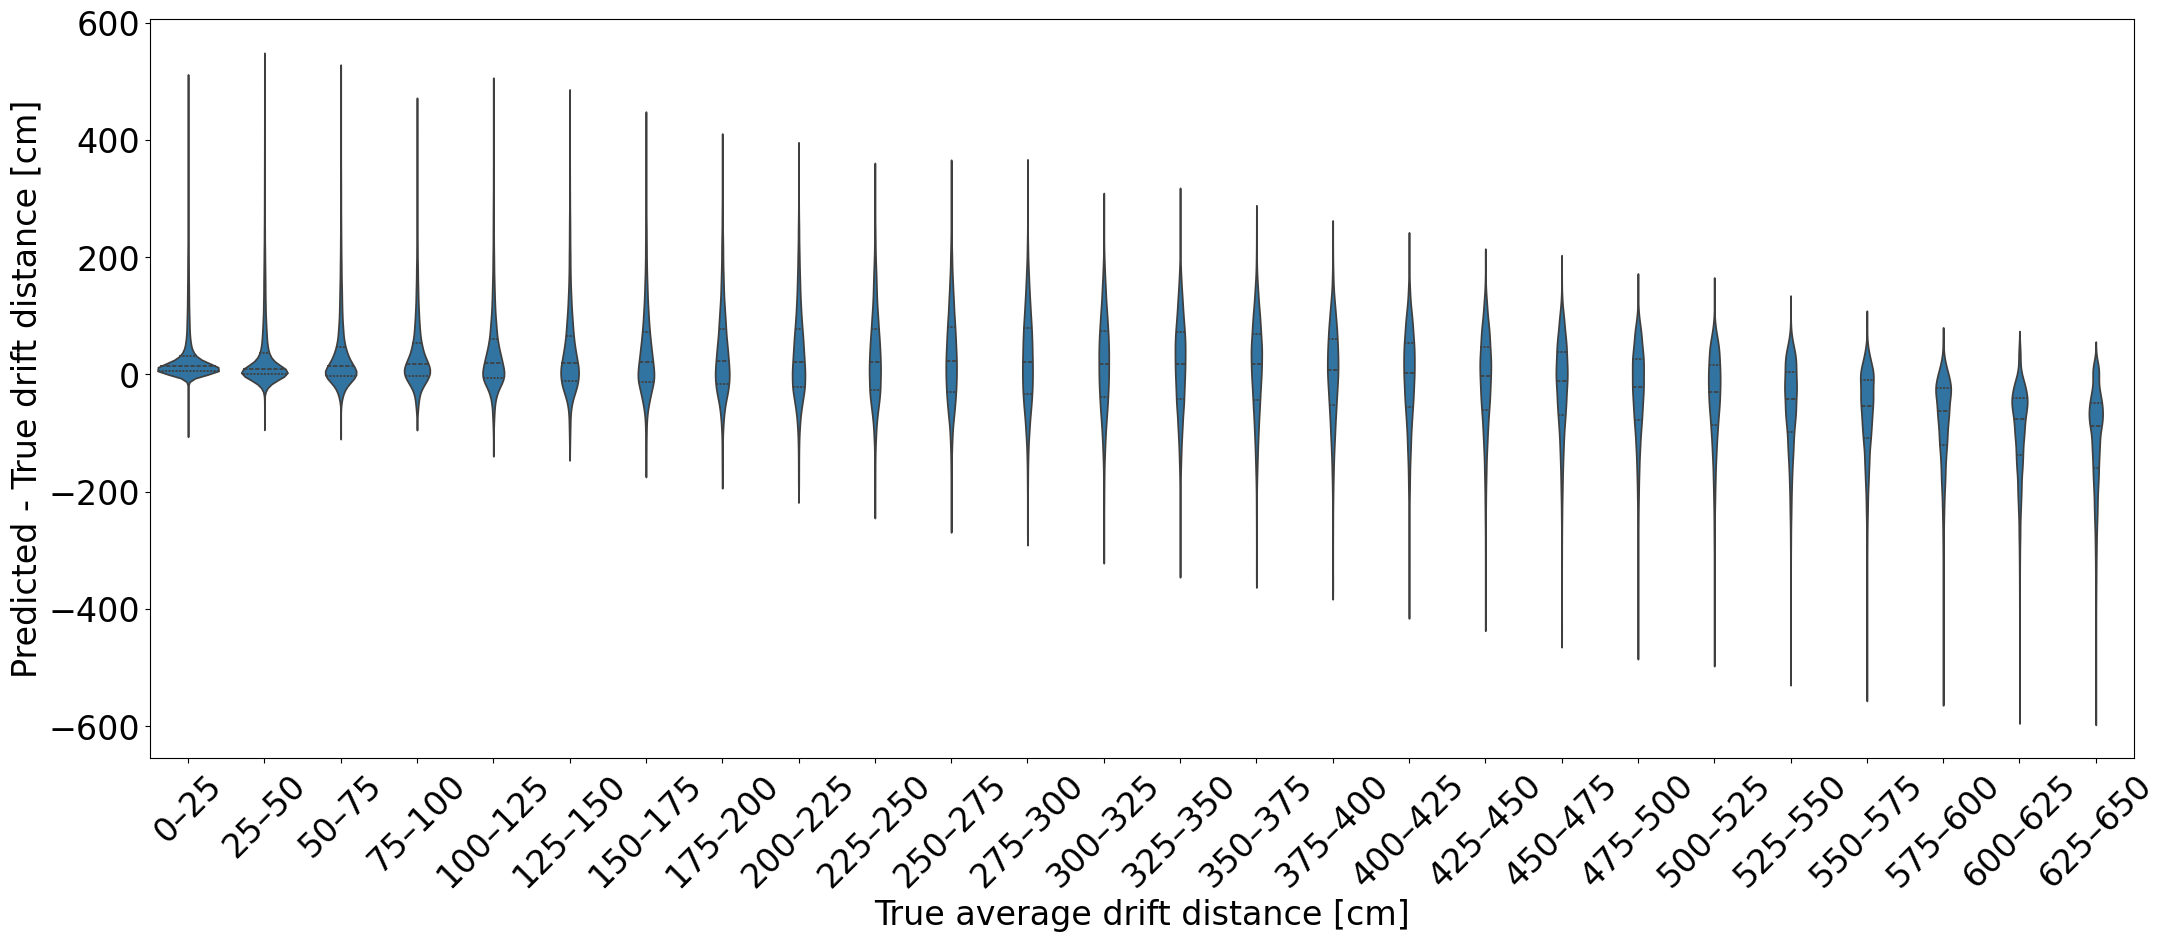

In [23]:
fig, ax = plt.subplots(figsize = (25.6, 9.6))
plt.rcParams.update({"font.size": 24,
                     "axes.labelsize": 24,
                     "xtick.labelsize": 30,
                     "ytick.labelsize": 30,})

sns.violinplot(data = df, x = "drift_bin_label", y = "drift_diff", inner = "quartile", cut = 0)

ax.tick_params(axis = 'x', labelrotation = 45)
ax.set_xlabel("True average drift distance [cm]")
ax.set_ylabel("Predicted - True drift distance [cm]")

In [24]:
summary = (
    df.groupby("drift_bin")["drift_diff"]
    .quantile([0.16, 0.50, 0.84])
    .unstack()
    .rename(columns = {0.16: "q16", 0.50: "q50", 0.84: "q84"})
    .reset_index()
)

summary["drift_bin_center"] = summary["drift_bin"].apply(lambda b: (b.left + b.right) / 2)
summary["err_low"] = summary["q50"] - summary["q16"]
summary["err_high"] = summary["q84"] - summary["q50"]

/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_7703/1822938074.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("drift_bin")["drift_diff"]


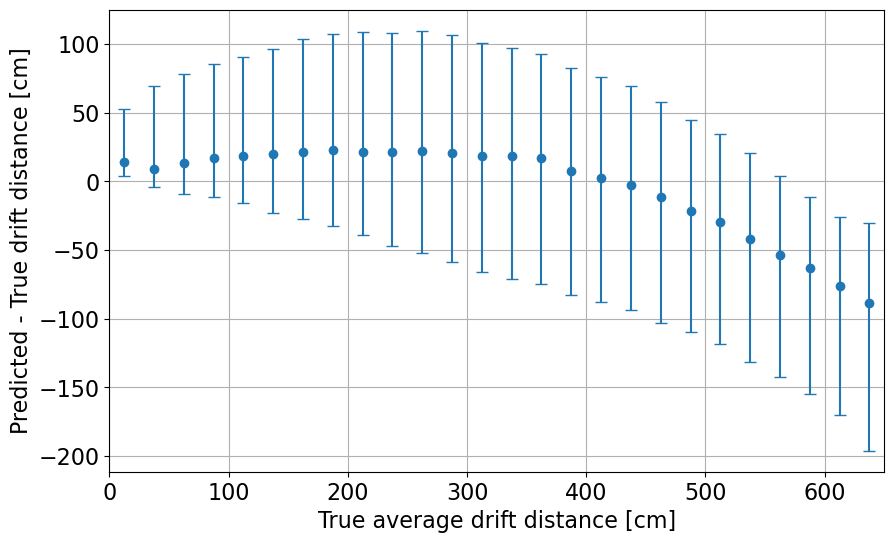

In [25]:
plt.rcParams.update({"font.size": 16,
                     "axes.labelsize": 16,
                     "xtick.labelsize": 16,
                     "ytick.labelsize": 16,})

fig, ax = plt.subplots(figsize = (10, 6))

ax.errorbar(
    summary["drift_bin_center"],
    summary["q50"],
    yerr = [summary["err_low"], summary["err_high"]],
    fmt = 'o',
    capsize = 4
)
ax.set_xlabel("True average drift distance [cm]")
ax.set_ylabel("Predicted - True drift distance [cm]")
ax.grid()
ax.set_xlim([0, 650])
plt.show()

In [26]:
def plot_drift_performance(
    df,
    truth_col = "drift_avg",
    pred_col = "pred_drift",
    bin_width = 25,
    min_entries = 1,
    figsize_violin = (12, 6),
    figsize_summary = (8, 5),
    min_val = 0,
    max_val = 650
):
    """
    Make violin, bias, resolution, relative bias, and relative resolution plots.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe containing truth and prediction columns.
    truth_col : str
        Column name for true/reference value.
    pred_col : str
        Column name for predicted value.
    bin_width : float
        Width of truth bins, e.g. 20 for 20 cm bins.
    min_entries : int
        Minimum number of entries required in a bin to keep it.
    figsize_violin : tuple
        Figure size for violin plot.
    figsize_summary : tuple
        Figure size for summary plots.

    Returns
    -------
    work_df : pandas.DataFrame
        Copy of input dataframe with derived columns.
    summary : pandas.DataFrame
        Summary table with quantiles and derived metrics.
    """

    work_df = df.copy()

    # keep only finite values
    work_df = work_df[np.isfinite(work_df[truth_col]) & np.isfinite(work_df[pred_col])].copy()

    # derived columns
    work_df["diff"] = work_df[pred_col] - work_df[truth_col]

    # for relative quantities avoid division by zero
    work_df["rel_diff"] = np.nan
    nonzero = work_df[truth_col] != 0
    work_df.loc[nonzero, "rel_diff"] = (
        work_df.loc[nonzero, "diff"] / work_df.loc[nonzero, truth_col]
    )

    # define bins
    # min_val = np.floor(work_df[truth_col].min() / bin_width) * bin_width
    # max_val = np.ceil(work_df[truth_col].max() / bin_width) * bin_width
    bins = np.arange(min_val, max_val + bin_width, bin_width)

    work_df["drift_bin"] = pd.cut(work_df[truth_col], bins = bins, right = False)

    # remove empty / too-small bins
    counts = work_df["drift_bin"].value_counts().sort_index()
    valid_bins = counts[counts >= min_entries].index
    work_df = work_df[work_df["drift_bin"].isin(valid_bins)].copy()

    # ordered labels for plotting
    work_df["drift_bin_label"] = work_df["drift_bin"].apply(
        lambda x: f"[{int(x.left)}, {int(x.right)})"
    )

    # absolute summary
    abs_summary = (
        work_df.groupby("drift_bin")["diff"]
        .quantile([0.16, 0.50, 0.84])
        .unstack()
        .rename(columns = {0.16: "diff_q16", 0.50: "diff_q50", 0.84: "diff_q84"})
    )

    # relative summary
    rel_summary = (
        work_df.dropna(subset = ["rel_diff"])
        .groupby("drift_bin")["rel_diff"]
        .quantile([0.16, 0.50, 0.84])
        .unstack()
        .rename(columns = {0.16: "rel_q16", 0.50: "rel_q50", 0.84: "rel_q84"})
    )

    # counts and x positions
    count_summary = work_df.groupby("drift_bin").size().to_frame("count")

    summary = abs_summary.join(rel_summary, how = "left").join(count_summary, how = "left").reset_index()

    summary["x_center"] = summary["drift_bin"].apply(lambda b: (b.left + b.right) / 2)
    summary["bin_label"] = summary["drift_bin"].apply(lambda b: f"[{int(b.left)}, {int(b.right)})")

    # absolute bias/resolution
    summary["bias"] = summary["diff_q50"]
    summary["bias_err_low"] = summary["diff_q50"] - summary["diff_q16"]
    summary["bias_err_high"] = summary["diff_q84"] - summary["diff_q50"]
    summary["resolution"] = (summary["diff_q84"] - summary["diff_q16"]) / 2.0

    # relative bias/resolution
    summary["rel_bias"] = summary["rel_q50"]
    summary["rel_bias_err_low"] = summary["rel_q50"] - summary["rel_q16"]
    summary["rel_bias_err_high"] = summary["rel_q84"] - summary["rel_q50"]
    summary["rel_resolution"] = (summary["rel_q84"] - summary["rel_q16"]) / 2.0


    # Plot parameters
    plt.rcParams.update({"font.size": 18,
                     "axes.labelsize": 18,
                     "xtick.labelsize": 18,
                     "ytick.labelsize": 18,})

    # --------------------
    # 1. Violin plot
    # --------------------
    fig, ax = plt.subplots(figsize = figsize_violin)
    
    sns.violinplot(
        data = work_df,
        x = "drift_bin_label",
        y = "diff",
        inner = "quartile",
        cut = 0,
        ax = ax
    )
    ax.set_xlabel(f"True average drift distance [cm]")
    ax.set_ylabel(f"Predicted - True drift distance [cm]")
    # ax.set_title("Distribution of prediction residuals by truth bin")
    ax.tick_params(axis = "x", labelrotation = 45)
    plt.tight_layout()
    plt.show()

    # --------------------
    # 2. Bias plot
    # --------------------
    fig, ax = plt.subplots(figsize = figsize_summary)
    
    ax.errorbar(
        summary["x_center"],
        summary["bias"],
        yerr = [summary["bias_err_low"], summary["bias_err_high"]],
        fmt = "o-",
        capsize = 4
    )
    ax.axhline(0, color = "gray", linestyle = "--")
    ax.set_xlabel("True average drift distance [cm]")
    ax.set_ylabel("Median of the Difference [cm]")
    ax.set_title("Prediction bias")
    ax.set_xlim([0, 650])
    ax.grid()
    
    plt.tight_layout()
    plt.show()

    # --------------------
    # 3. Resolution plot
    # --------------------
    fig, ax = plt.subplots(figsize = figsize_summary)
    
    ax.plot(summary["x_center"], summary["resolution"], "o-")
    ax.set_xlabel("True average drift distance [cm]")
    ax.set_ylabel("(q84 - q16)/2 of the Difference [cm]")
    ax.set_title("Resolution vs truth")
    ax.set_xlim([0, 650])
    ax.grid()

    plt.tight_layout()
    plt.show()

    # --------------------
    # 4. Relative bias plot
    # --------------------
    fig, ax = plt.subplots(figsize = figsize_summary)
    
    ax.errorbar(
        summary["x_center"],
        summary["rel_bias"],
        yerr = [summary["rel_bias_err_low"], summary["rel_bias_err_high"]],
        fmt = "o-",
        capsize = 4
    )
    ax.axhline(0, color = "gray", linestyle = "--")
    ax.set_xlabel("True average drift distance [cm]")
    ax.set_ylabel(f"Median of the relative difference")
    ax.set_title("Relative Bias vs truth")
    ax.set_xlim([0, 650])
    ax.grid()
    # ax.set_yscale('log')
    plt.tight_layout()
    plt.show()

    # ---------------------------
    # 5. Relative resolution plot
    # ---------------------------
    fig, ax = plt.subplots(figsize = figsize_summary)
    
    ax.plot(summary["x_center"], summary["rel_resolution"], "o-")
    ax.set_xlabel("True average drift distance [cm]")
    ax.set_ylabel("(q84 - q16)/2 of the relative difference")
    ax.set_title("Relative Resolution vs truth")
    ax.set_xlim([0, 650])
    ax.grid()
    # ax.set_yscale('log')
    plt.tight_layout()
    plt.show()

    # --------------------------------------------
    # 6. Relative bias plot - y range [-0.2, 1]
    # --------------------------------------------
    fig, ax = plt.subplots(figsize = figsize_summary)
    
    ax.errorbar(
        summary["x_center"],
        summary["rel_bias"],
        yerr = [summary["rel_bias_err_low"], summary["rel_bias_err_high"]],
        fmt = "o-",
        capsize = 4
    )
    ax.axhline(0, color = "gray", linestyle = "--")
    ax.set_xlabel("True average drift distance [cm]")
    ax.set_ylabel(f"Median of the relative difference")
    ax.set_title("Relative Bias vs truth")
    ax.set_xlim([0, 650])
    ax.set_ylim([-0.3, 1])
    ax.grid()
    # ax.set_yscale('log')
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------
    # 7. Relative resolution plot - y range [0, 1]
    # --------------------------------------------------
    fig, ax = plt.subplots(figsize = figsize_summary)
    
    ax.plot(summary["x_center"], summary["rel_resolution"], "o-")
    ax.set_xlabel("True average drift distance [cm]")
    ax.set_ylabel("(q84 - q16)/2 of the relative difference")
    ax.set_title("Relative Resolution vs truth")
    ax.set_xlim([0, 650])
    ax.set_ylim([0, 1])
    ax.grid()
    # ax.set_yscale('log')
    plt.tight_layout()
    plt.show()

    return work_df, summary

/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_7703/2388604362.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  work_df.groupby("drift_bin")["diff"]
/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_7703/2388604362.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("drift_bin")["rel_diff"]
/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_7703/2388604362.py:90: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future defau

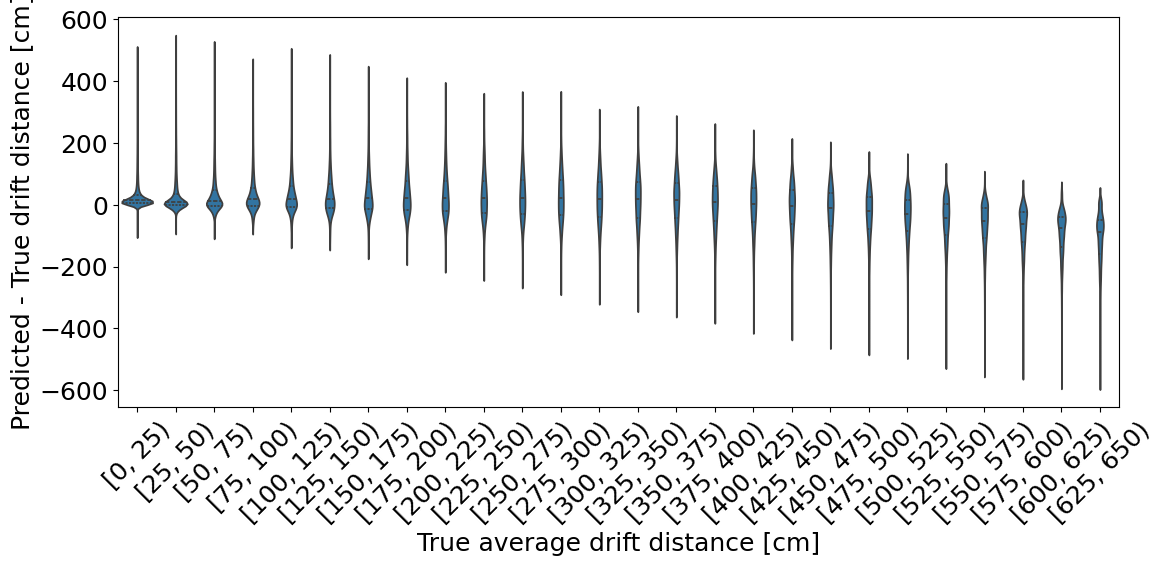

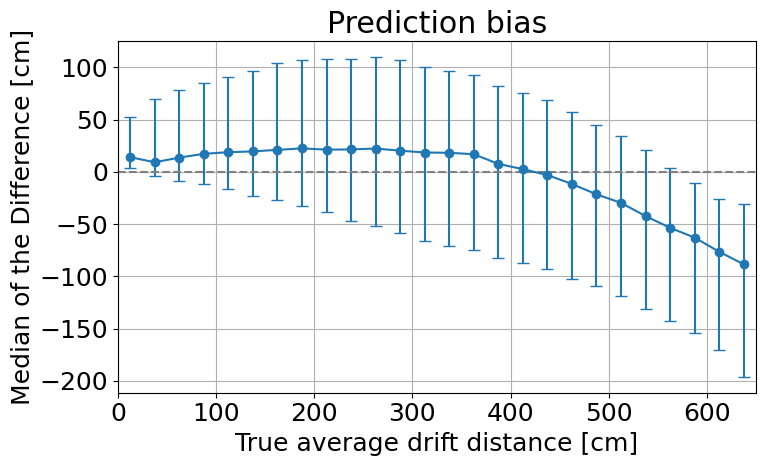

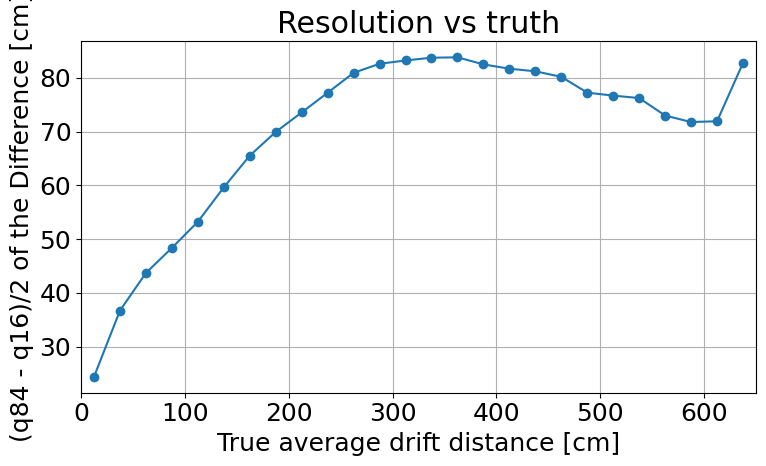

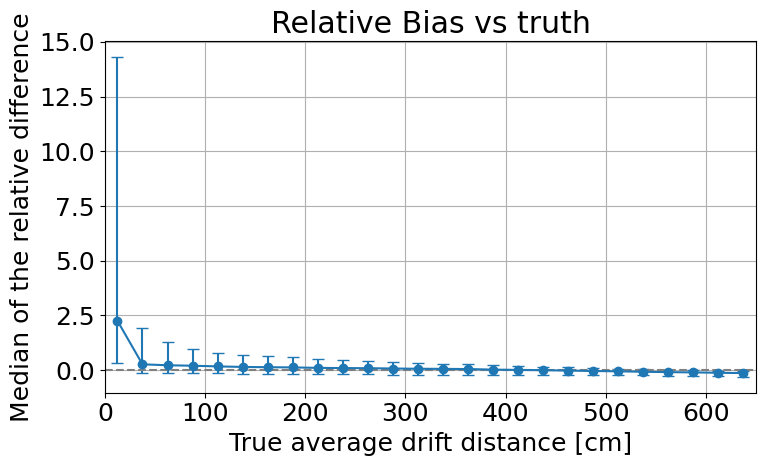

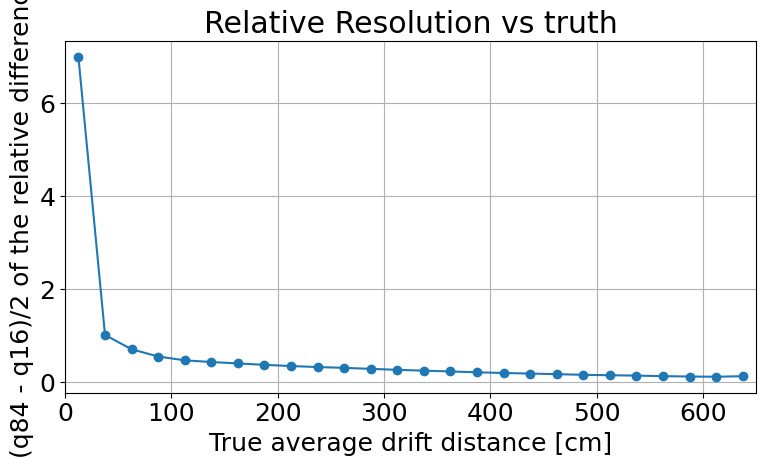

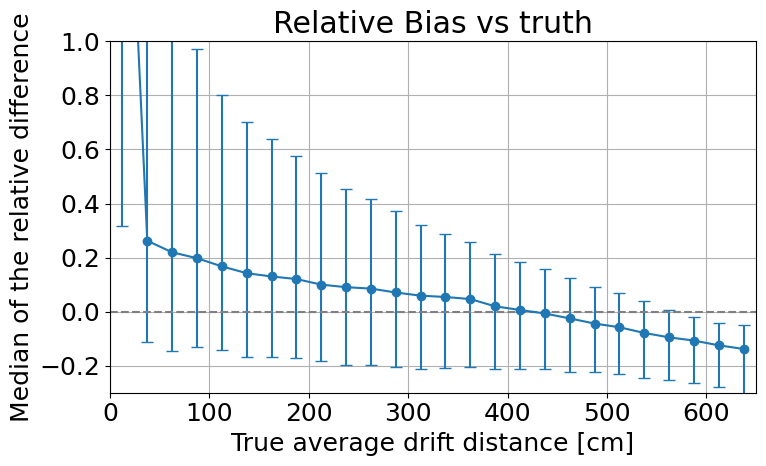

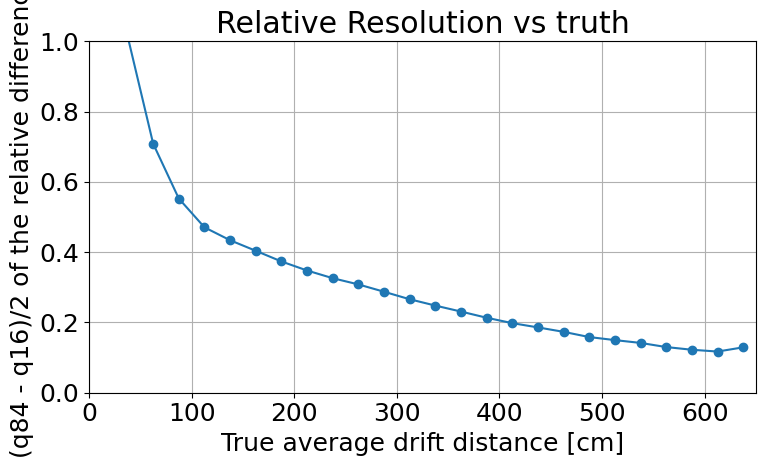

In [27]:
work_df, summary = plot_drift_performance(
    df,
    truth_col = "drift_avg",
    pred_col = "pred_drift",
    bin_width = 25
)